# 02 · Construcción Dataset Empresa V3 (4 niveles de riesgo)

**Objetivo:** construir un dataset de empresas con mayor granularidad, usando la unidad **empresa–participación/vínculo** y una etiqueta proxy ordinal de **4 niveles de riesgo**.

## Niveles de riesgo
- `0`: Sin señales relevantes
- `1`: Riesgo bajo
- `2`: Riesgo medio
- `3`: Riesgo alto/extremo

> Nota metodológica: los archivos de empresa no contienen una columna explícita `RIESGO_EMPRESA`. Por ello, este notebook construye una **etiqueta proxy** basada en señales observables como sanciones, inhabilitaciones, impedimentos y alertas. Las variables usadas para crear la etiqueta se excluyen del entrenamiento para reducir leakage.

In [1]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")

try:
    import matplotlib.pyplot as plt
except Exception:
    plt = None

# -------------------------------------------------
# Configuración de raíz del proyecto
# -------------------------------------------------
PROJECT_ROOT_MANUAL = Path(r"C:\IA_Investigacion\Deteccion_Corrupcion")

def find_project_root(start: Path | None = None) -> Path:
    """
    Detecta la raíz del proyecto. Si PROJECT_ROOT_MANUAL existe, la usa.
    Si no, sube por padres hasta encontrar README + data/external.
    """
    if PROJECT_ROOT_MANUAL.exists():
        return PROJECT_ROOT_MANUAL

    start = start or Path.cwd()
    candidates = [start, *start.parents]

    for c in candidates:
        has_readme = (c / "README.md").exists()
        has_data_external = (c / "data" / "external").exists()
        has_src_or_req = (c / "src").exists() or (c / "requirements.txt").exists() or (c / "pyproject.toml").exists()
        if has_readme and has_data_external and has_src_or_req:
            return c

    raise FileNotFoundError(
        "No se pudo detectar la raíz del proyecto. Ajusta PROJECT_ROOT_MANUAL."
    )

BASE = find_project_root()
DATA_EXT = BASE / "data" / "external" / "empresa"
DATA_PROC = BASE / "data" / "processed"
REPORTS = BASE / "reports" / "figures"

DATA_PROC.mkdir(parents=True, exist_ok=True)
REPORTS.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("DATA_EXT:", DATA_EXT)
print("DATA_PROC:", DATA_PROC)
print("REPORTS:", REPORTS)

BASE: C:\IA_Investigacion\Deteccion_Corrupcion
DATA_EXT: C:\IA_Investigacion\Deteccion_Corrupcion\data\external\empresa
DATA_PROC: C:\IA_Investigacion\Deteccion_Corrupcion\data\processed
REPORTS: C:\IA_Investigacion\Deteccion_Corrupcion\reports\figures


## 1. Lectura robusta de archivos de empresa

In [2]:
EMPRESA_FILES = [
    "DS_DASH_Empresa_1A.csv",
    "DS_DASH_Empresa_1B.csv",
    "DS_DASH_Empresa_2A.csv",
    "DS_DASH_Empresa_2B.csv",
    "DS_DASH_Empresa_2C.csv",
]

def read_csv_robust(path: Path, nrows: int | None = None) -> tuple[pd.DataFrame, str]:
    encodings = ["utf-8-sig", "utf-8", "latin1", "cp1252"]
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc, nrows=nrows)
            return df, enc
        except Exception as exc:
            last_error = exc
    raise RuntimeError(f"No se pudo leer {path}. Último error: {last_error}")

tablas = {}
lecturas = []

for fname in EMPRESA_FILES:
    path = DATA_EXT / fname
    if not path.exists():
        raise FileNotFoundError(f"No existe el archivo requerido: {path}")

    df, enc = read_csv_robust(path)
    tablas[fname] = df

    lecturas.append({
        "archivo": fname,
        "encoding": enc,
        "filas": len(df),
        "columnas": df.shape[1],
        "columnas_lista": list(df.columns)
    })

resumen_lectura = pd.DataFrame(lecturas)
resumen_lectura[["archivo", "encoding", "filas", "columnas"]]

,archivo,encoding,filas,columnas
0,DS_DASH_Empresa_1A.csv,latin1,553,9
1,DS_DASH_Empresa_1B.csv,latin1,2148,5
2,DS_DASH_Empresa_2A.csv,latin1,371,11
3,DS_DASH_Empresa_2B.csv,latin1,5395,4
4,DS_DASH_Empresa_2C.csv,utf-8-sig,26,2


## 2. Perfilamiento inicial: llaves, nulos y granularidad

In [3]:
def normalizar_codigo(s: pd.Series) -> pd.Series:
    return (
        s.astype(str)
         .str.strip()
         .replace({"nan": np.nan, "None": np.nan, "": np.nan})
    )

# Normalizar columnas de RUC y códigos
for df in tablas.values():
    for col in df.columns:
        col_upper = col.upper()
        if "RUC" in col_upper or col_upper.startswith("CODIGO"):
            df[col] = normalizar_codigo(df[col])

perfil = []

for fname, df in tablas.items():
    row = {
        "archivo": fname,
        "filas": len(df),
        "columnas": df.shape[1],
        "pct_nulos_total": round(float(df.isna().mean().mean()), 4)
    }

    for col in ["CODIGO_RUC", "CODIGO_RUC_GANADOR", "CODIGO_RUC_PARTICIPANTE", "CODIGO_OBRA"]:
        if col in df.columns:
            row[f"{col}_unicos"] = int(df[col].nunique(dropna=True))
        else:
            row[f"{col}_unicos"] = None

    perfil.append(row)

perfil_df = pd.DataFrame(perfil)
perfil_df

,archivo,filas,columnas,pct_nulos_total,CODIGO_RUC_unicos,CODIGO_RUC_GANADOR_unicos,CODIGO_RUC_PARTICIPANTE_unicos,CODIGO_OBRA_unicos
0,DS_DASH_Empresa_1A.csv,553,9,0.0000,371.0,NaN,NaN,230.0
1,DS_DASH_Empresa_1B.csv,2148,5,0.0000,293.0,NaN,NaN,180.0
2,DS_DASH_Empresa_2A.csv,371,11,0.0497,371.0,NaN,NaN,NaN
3,DS_DASH_Empresa_2B.csv,5395,4,0.0000,NaN,380.0,952.0,NaN
4,DS_DASH_Empresa_2C.csv,26,2,0.0000,NaN,26.0,NaN,NaN


In [4]:
# Top de nulos por archivo
for fname, df in tablas.items():
    print("\n" + "="*90)
    print(fname, df.shape)
    print("Columnas:", list(df.columns))
    print("\nNulos top:")
    print((df.isna().mean() * 100).sort_values(ascending=False).head(10).round(2))


DS_DASH_Empresa_1A.csv (553, 9)
Columnas: ['CODIGO_OBRA', 'CODIGO_RUC', 'NOMBRE_EMPRESA', 'EsConsorcio', 'SANCIONADAS_TCE', 'INHABILITADAS_PJ', 'SANCIONADAS_RNP', 'INHABILITADAS_RNP', 'IMPEDIDAS_RNP']

Nulos top:
CODIGO_OBRA          0.0
CODIGO_RUC           0.0
NOMBRE_EMPRESA       0.0
EsConsorcio          0.0
SANCIONADAS_TCE      0.0
INHABILITADAS_PJ     0.0
SANCIONADAS_RNP      0.0
INHABILITADAS_RNP    0.0
IMPEDIDAS_RNP        0.0
dtype: float64

DS_DASH_Empresa_1B.csv (2148, 5)
Columnas: ['CODIGO_OBRA', 'CODIGO_RUC', 'NOMBRE_EMPRESA', 'DNI_REPRESENTANTE_LEGAL', 'NOMBRE_REPRESENTANTE_LEGAL']

Nulos top:
CODIGO_OBRA                   0.0
CODIGO_RUC                    0.0
NOMBRE_EMPRESA                0.0
DNI_REPRESENTANTE_LEGAL       0.0
NOMBRE_REPRESENTANTE_LEGAL    0.0
dtype: float64

DS_DASH_Empresa_2A.csv (371, 11)
Columnas: ['CODIGO_RUC', 'NOMBRE_EMPRESA', 'CAPACIDAD_MAXIMA_CONTRATACION', 'CAPACIDAD_LIBRE_CONTRATACION', 'ESTADO', 'CONDICION', 'NUMERO_SANCIONES_TCE', 'NUMERO_SAN

## 3. Interpretación de granularidad

Los archivos de empresa tienen más de una unidad de análisis:

- `Empresa_1A`: empresa asociada a obra, con señales de sanción/inhabilitación.
- `Empresa_1B`: representantes legales por empresa y obra.
- `Empresa_2A`: perfil único por RUC.
- `Empresa_2B`: vínculos ganador–participante.
- `Empresa_2C`: datos adicionales de ganadores/ofertas.

Para aumentar la cantidad de registros sin inventar datos, se construye un dataset granular **empresa–vínculo**, creando filas para:
- empresa como `ganador`
- empresa como `participante`

El split de entrenamiento se hará por grupo `CODIGO_RUC`, para evitar que la misma empresa aparezca en train y test.

## 4. Construcción de señales y target proxy de riesgo empresa

In [5]:
df_1a = tablas["DS_DASH_Empresa_1A.csv"].copy()
df_1b = tablas["DS_DASH_Empresa_1B.csv"].copy()
df_2a = tablas["DS_DASH_Empresa_2A.csv"].copy()
df_2b = tablas["DS_DASH_Empresa_2B.csv"].copy()
df_2c = tablas["DS_DASH_Empresa_2C.csv"].copy()

def flag_sancion(s: pd.Series) -> pd.Series:
    """
    Convierte textos como 'SANCIONADA' / 'EN SITUACION NORMAL' a 1/0.
    """
    return (
        s.astype(str)
         .str.upper()
         .str.contains("SANCION|INHABIL|IMPED", regex=True, na=False)
         .astype(int)
    )

def flag_alerta(s: pd.Series) -> pd.Series:
    """
    Convierte textos como 'ALERTA' / 'NORMAL' a 1/0.
    """
    return (
        s.astype(str)
         .str.upper()
         .str.contains("ALERTA|SANCION|INHABIL|IMPED", regex=True, na=False)
         .astype(int)
    )

# Señales desde 1A: sanciones e inhabilitaciones por empresa
for col in ["SANCIONADAS_TCE", "INHABILITADAS_PJ", "SANCIONADAS_RNP", "INHABILITADAS_RNP", "IMPEDIDAS_RNP"]:
    if col in df_1a.columns:
        df_1a[f"flag_{col.lower()}"] = flag_sancion(df_1a[col])

agg_1a = df_1a.groupby("CODIGO_RUC", dropna=True).agg(
    nombre_empresa_1a=("NOMBRE_EMPRESA", "first"),
    n_obras_asociadas_1a=("CODIGO_OBRA", "nunique"),
    n_registros_1a=("CODIGO_RUC", "count"),
    es_consorcio=("EsConsorcio", lambda s: int(s.astype(str).str.upper().str.contains("SI|TRUE|1", regex=True, na=False).any())),
    flag_sancionadas_tce=("flag_sancionadas_tce", "max"),
    flag_inhabilitadas_pj=("flag_inhabilitadas_pj", "max"),
    flag_sancionadas_rnp=("flag_sancionadas_rnp", "max"),
    flag_inhabilitadas_rnp=("flag_inhabilitadas_rnp", "max"),
    flag_impedidas_rnp=("flag_impedidas_rnp", "max"),
).reset_index()

# Señales desde 2A: capacidad, estado, condición y alertas
for col in ["NUMERO_SANCIONES_TCE", "NUMERO_SANCIONES_RNP"]:
    if col in df_2a.columns:
        df_2a[col] = pd.to_numeric(df_2a[col], errors="coerce").fillna(0)

for col in ["FECHA_CONSTITUCION_ALERTA", "LEY_SELVA_ALERTA", "ACCIONISTAS_ALERTA"]:
    if col in df_2a.columns:
        df_2a[f"flag_{col.lower()}"] = flag_alerta(df_2a[col])

agg_2a = df_2a.groupby("CODIGO_RUC", dropna=True).agg(
    nombre_empresa_2a=("NOMBRE_EMPRESA", "first"),
    capacidad_maxima_contratacion=("CAPACIDAD_MAXIMA_CONTRATACION", "first"),
    capacidad_libre_contratacion=("CAPACIDAD_LIBRE_CONTRATACION", "first"),
    estado_empresa=("ESTADO", "first"),
    condicion_empresa=("CONDICION", "first"),
    numero_sanciones_tce=("NUMERO_SANCIONES_TCE", "max"),
    numero_sanciones_rnp=("NUMERO_SANCIONES_RNP", "max"),
    flag_fecha_constitucion_alerta=("flag_fecha_constitucion_alerta", "max"),
    flag_ley_selva_alerta=("flag_ley_selva_alerta", "max"),
    flag_accionistas_alerta=("flag_accionistas_alerta", "max"),
).reset_index()

# Representantes legales desde 1B
agg_1b = df_1b.groupby("CODIGO_RUC", dropna=True).agg(
    n_obras_representante=("CODIGO_OBRA", "nunique"),
    n_representantes_legales=("DNI_REPRESENTANTE_LEGAL", "nunique"),
    representante_legal_principal=("NOMBRE_REPRESENTANTE_LEGAL", "first"),
).reset_index()

empresa_base = (
    agg_1a
    .merge(agg_2a, on="CODIGO_RUC", how="outer")
    .merge(agg_1b, on="CODIGO_RUC", how="left")
)

# Nombre consolidado
empresa_base["NOMBRE_EMPRESA"] = empresa_base["nombre_empresa_1a"].fillna(empresa_base["nombre_empresa_2a"])

# Completar flags numéricos
flag_cols = [
    "flag_sancionadas_tce", "flag_inhabilitadas_pj", "flag_sancionadas_rnp",
    "flag_inhabilitadas_rnp", "flag_impedidas_rnp",
    "numero_sanciones_tce", "numero_sanciones_rnp",
    "flag_fecha_constitucion_alerta", "flag_ley_selva_alerta", "flag_accionistas_alerta",
]
for col in flag_cols:
    if col in empresa_base.columns:
        empresa_base[col] = pd.to_numeric(empresa_base[col], errors="coerce").fillna(0)

# Score proxy
empresa_base["risk_score_proxy"] = 0

empresa_base["risk_score_proxy"] += 3 * (
    (empresa_base["flag_inhabilitadas_pj"] > 0) |
    (empresa_base["flag_inhabilitadas_rnp"] > 0) |
    (empresa_base["flag_impedidas_rnp"] > 0)
).astype(int)

empresa_base["risk_score_proxy"] += 2 * (
    (empresa_base["flag_sancionadas_tce"] > 0) |
    (empresa_base["flag_sancionadas_rnp"] > 0) |
    (empresa_base["numero_sanciones_tce"] > 0) |
    (empresa_base["numero_sanciones_rnp"] > 0)
).astype(int)

empresa_base["risk_score_proxy"] += 1 * (
    (empresa_base["flag_fecha_constitucion_alerta"] > 0) |
    (empresa_base["flag_ley_selva_alerta"] > 0) |
    (empresa_base["flag_accionistas_alerta"] > 0)
).astype(int)

def score_to_4niveles(score: float) -> int:
    if score <= 0:
        return 0
    if score <= 2:
        return 1
    if score <= 4:
        return 2
    return 3

empresa_base["y_riesgo_empresa_4niveles"] = empresa_base["risk_score_proxy"].apply(score_to_4niveles).astype(int)

print("Empresa base:", empresa_base.shape)
print("Empresas únicas:", empresa_base["CODIGO_RUC"].nunique())
print("\nDistribución target empresa única:")
print(empresa_base["y_riesgo_empresa_4niveles"].value_counts().sort_index())

empresa_base.head()

Empresa base: (371, 26)
Empresas únicas: 371

Distribución target empresa única:
y_riesgo_empresa_4niveles
0    203
1     17
2    120
3     31
Name: count, dtype: int64


,CODIGO_RUC,nombre_empresa_1a,n_obras_asociadas_1a,n_registros_1a,es_consorcio,flag_sancionadas_tce,flag_inhabilitadas_pj,flag_sancionadas_rnp,flag_inhabilitadas_rnp,flag_impedidas_rnp,...,numero_sanciones_rnp,flag_fecha_constitucion_alerta,flag_ley_selva_alerta,flag_accionistas_alerta,n_obras_representante,n_representantes_legales,representante_legal_principal,NOMBRE_EMPRESA,risk_score_proxy,y_riesgo_empresa_4niveles
0,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,1,1,1,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,CONSULTORES ASOCIADOS DEL ORIENTE,0,0
1,10011010534,DELGADO VASQUEZ GEICEN BLADISLAV(*),1,1,1,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,DELGADO VASQUEZ GEICEN BLADISLAV(*),0,0
2,10011217104,CONSORCIO CONSULTOR B3,1,1,1,0,0,0,0,0,...,0,0,0,0,1.0,2.0,SIMON MUCHA MONICA LUZ,CONSORCIO CONSULTOR B3,0,0
3,10011600447,CHAVEZ BRAVO DAGOBERTO,1,1,0,0,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,CHAVEZ BRAVO DAGOBERTO,0,0
4,10020343112,TICONA VARGAS TOMAS(*),3,3,1,0,0,0,0,0,...,0,0,0,0,2.0,1.0,BECERRA GUEVARA RICARDO LENIN,TICONA VARGAS TOMAS(*),0,0


## 5. Dataset granular empresa–vínculo desde Empresa_2B

In [6]:
# Empresa_2B contiene relación ganador-participante. La convertimos a formato largo.
ganadores = df_2b.rename(columns={
    "CODIGO_RUC_GANADOR": "CODIGO_RUC",
    "NOMBRE_GANADOR": "NOMBRE_EMPRESA_ROL",
    "CODIGO_RUC_PARTICIPANTE": "RUC_CONTRAPARTE",
    "NOMBRE_PARTICIPANTE": "NOMBRE_CONTRAPARTE",
}).copy()
ganadores["rol_empresa"] = "ganador"

participantes = df_2b.rename(columns={
    "CODIGO_RUC_PARTICIPANTE": "CODIGO_RUC",
    "NOMBRE_PARTICIPANTE": "NOMBRE_EMPRESA_ROL",
    "CODIGO_RUC_GANADOR": "RUC_CONTRAPARTE",
    "NOMBRE_GANADOR": "NOMBRE_CONTRAPARTE",
}).copy()
participantes["rol_empresa"] = "participante"

cols_vinculo = ["CODIGO_RUC", "NOMBRE_EMPRESA_ROL", "RUC_CONTRAPARTE", "NOMBRE_CONTRAPARTE", "rol_empresa"]
df_vinculos = pd.concat(
    [ganadores[cols_vinculo], participantes[cols_vinculo]],
    ignore_index=True
)

df_vinculos["CODIGO_RUC"] = normalizar_codigo(df_vinculos["CODIGO_RUC"])
df_vinculos["RUC_CONTRAPARTE"] = normalizar_codigo(df_vinculos["RUC_CONTRAPARTE"])

print("Dataset vínculos crudo:", df_vinculos.shape)
print("Empresas únicas en vínculos:", df_vinculos["CODIGO_RUC"].nunique())
print(df_vinculos["rol_empresa"].value_counts())

df_vinculos.head()

Dataset vínculos crudo: (10790, 5)
Empresas únicas en vínculos: 952
rol_empresa
ganador         5395
participante    5395
Name: count, dtype: int64


,CODIGO_RUC,NOMBRE_EMPRESA_ROL,RUC_CONTRAPARTE,NOMBRE_CONTRAPARTE,rol_empresa
0,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,10086051546,CONSORCIO SUPERVISOR AREQUIPA-LAJOYA,ganador
1,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20100153671,LAGESA INGENIEROS CONSULTORES S.A.(*),ganador
2,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,ganador
3,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20112860381,CONSORCIO SUPERVISOR AREQUIPA,ganador
4,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20137114705,SERVICIO DE CONSULTORES ANDINOS SOCIEDAD ANONIMA,ganador


## 6. Agregados de participación y ofertas

In [7]:
# Agregados desde vínculos
agg_vinculos = df_vinculos.groupby("CODIGO_RUC", dropna=True).agg(
    n_vinculos_total=("CODIGO_RUC", "count"),
    n_contrapartes_unicas=("RUC_CONTRAPARTE", "nunique"),
    n_veces_ganador=("rol_empresa", lambda s: int((s == "ganador").sum())),
    n_veces_participante=("rol_empresa", lambda s: int((s == "participante").sum())),
).reset_index()

agg_vinculos["ratio_ganador"] = agg_vinculos["n_veces_ganador"] / agg_vinculos["n_vinculos_total"].replace(0, np.nan)
agg_vinculos["ratio_participante"] = agg_vinculos["n_veces_participante"] / agg_vinculos["n_vinculos_total"].replace(0, np.nan)

# Agregados desde 2C: hora de presentación de oferta por ganador
if "CODIGO_RUC_GANADOR" in df_2c.columns:
    df_2c["CODIGO_RUC_GANADOR"] = normalizar_codigo(df_2c["CODIGO_RUC_GANADOR"])
    agg_2c = df_2c.groupby("CODIGO_RUC_GANADOR", dropna=True).agg(
        n_registros_hora_oferta=("HORA_PRESENTACION_OFERTA", "count"),
        n_horas_oferta_distintas=("HORA_PRESENTACION_OFERTA", "nunique"),
        hora_oferta_moda=("HORA_PRESENTACION_OFERTA", lambda s: s.mode().iloc[0] if len(s.mode()) else np.nan),
    ).reset_index().rename(columns={"CODIGO_RUC_GANADOR": "CODIGO_RUC"})
else:
    agg_2c = pd.DataFrame(columns=["CODIGO_RUC"])

empresa_features = (
    empresa_base
    .merge(agg_vinculos, on="CODIGO_RUC", how="left")
    .merge(agg_2c, on="CODIGO_RUC", how="left")
)

for col in ["n_vinculos_total", "n_contrapartes_unicas", "n_veces_ganador", "n_veces_participante", "n_registros_hora_oferta", "n_horas_oferta_distintas"]:
    if col in empresa_features.columns:
        empresa_features[col] = pd.to_numeric(empresa_features[col], errors="coerce").fillna(0)

print("Empresa features:", empresa_features.shape)
empresa_features.head()

Empresa features: (371, 35)


,CODIGO_RUC,nombre_empresa_1a,n_obras_asociadas_1a,n_registros_1a,es_consorcio,flag_sancionadas_tce,flag_inhabilitadas_pj,flag_sancionadas_rnp,flag_inhabilitadas_rnp,flag_impedidas_rnp,...,y_riesgo_empresa_4niveles,n_vinculos_total,n_contrapartes_unicas,n_veces_ganador,n_veces_participante,ratio_ganador,ratio_participante,n_registros_hora_oferta,n_horas_oferta_distintas,hora_oferta_moda
0,10001046191,CONSULTORES ASOCIADOS DEL ORIENTE,1,1,1,0,0,0,0,0,...,0,19,13,9,10,0.473684,0.526316,0.0,0.0,NaN
1,10011010534,DELGADO VASQUEZ GEICEN BLADISLAV(*),1,1,1,0,0,0,0,0,...,0,17,15,15,2,0.882353,0.117647,0.0,0.0,NaN
2,10011217104,CONSORCIO CONSULTOR B3,1,1,1,0,0,0,0,0,...,0,26,23,20,6,0.769231,0.230769,0.0,0.0,NaN
3,10011600447,CHAVEZ BRAVO DAGOBERTO,1,1,0,0,0,0,0,0,...,0,4,3,1,3,0.250000,0.750000,0.0,0.0,NaN
4,10020343112,TICONA VARGAS TOMAS(*),3,3,1,0,0,0,0,0,...,0,28,15,19,9,0.678571,0.321429,0.0,0.0,NaN


## 7. Dataset final granular: empresa–vínculo + features + target

In [8]:
df_empresa_v3 = df_vinculos.merge(
    empresa_features,
    on="CODIGO_RUC",
    how="left",
    suffixes=("", "_empresa")
)

# Si hubiera RUC en vínculos sin perfil, mantenerlos pero marcar target desconocido
df_empresa_v3["target_disponible"] = df_empresa_v3["y_riesgo_empresa_4niveles"].notna().astype(int)

print("Dataset granular empresa-vínculo:", df_empresa_v3.shape)
print("Empresas únicas:", df_empresa_v3["CODIGO_RUC"].nunique())
print("Target disponible:")
print(df_empresa_v3["target_disponible"].value_counts())

# Para modelado se usan solo filas con target conocido
df_model_raw = df_empresa_v3[df_empresa_v3["target_disponible"] == 1].copy()
df_model_raw["y_riesgo_empresa_4niveles"] = df_model_raw["y_riesgo_empresa_4niveles"].astype(int)

print("\nDataset modelable:", df_model_raw.shape)
print("Empresas únicas modelables:", df_model_raw["CODIGO_RUC"].nunique())
print("\nDistribución target granular:")
print(df_model_raw["y_riesgo_empresa_4niveles"].value_counts().sort_index())

Dataset granular empresa-vínculo: (10790, 40)
Empresas únicas: 952
Target disponible:
target_disponible
1    8047
0    2743
Name: count, dtype: int64

Dataset modelable: (8047, 40)
Empresas únicas modelables: 371

Distribución target granular:
y_riesgo_empresa_4niveles
0    3336
1     540
2    3049
3    1122
Name: count, dtype: int64


## 8. Control de leakage y limpieza

In [9]:
# Columnas usadas para construir el target: NO deben entrar al entrenamiento.
cols_leakage = [
    "risk_score_proxy",
    "flag_sancionadas_tce",
    "flag_inhabilitadas_pj",
    "flag_sancionadas_rnp",
    "flag_inhabilitadas_rnp",
    "flag_impedidas_rnp",
    "numero_sanciones_tce",
    "numero_sanciones_rnp",
    "flag_fecha_constitucion_alerta",
    "flag_ley_selva_alerta",
    "flag_accionistas_alerta",
    # textos originales equivalentes si aparecieran
    "SANCIONADAS_TCE",
    "INHABILITADAS_PJ",
    "SANCIONADAS_RNP",
    "INHABILITADAS_RNP",
    "IMPEDIDAS_RNP",
    "NUMERO_SANCIONES_TCE",
    "NUMERO_SANCIONES_RNP",
    "FECHA_CONSTITUCION_ALERTA",
    "LEY_SELVA_ALERTA",
    "ACCIONISTAS_ALERTA",
]

target_col = "y_riesgo_empresa_4niveles"

df_model = df_model_raw.drop(columns=cols_leakage, errors="ignore").copy()

# Eliminar columnas auxiliares que no convienen para baseline
aux_cols = [
    "target_disponible",
    "nombre_empresa_1a",
    "nombre_empresa_2a",
]
df_model = df_model.drop(columns=aux_cols, errors="ignore")

# Eliminar columnas 100% nulas
all_nan_cols = [c for c in df_model.columns if df_model[c].isna().all()]
if all_nan_cols:
    print("Eliminando columnas 100% nulas:", all_nan_cols)
    df_model = df_model.drop(columns=all_nan_cols)

# Eliminar columnas constantes, excepto target y grupo
constant_cols = [
    c for c in df_model.columns
    if c not in [target_col, "CODIGO_RUC"] and df_model[c].nunique(dropna=True) <= 1
]
if constant_cols:
    print("Eliminando columnas constantes:", constant_cols)
    df_model = df_model.drop(columns=constant_cols)

print("Dataset final modelado:", df_model.shape)
print("Columnas:", list(df_model.columns))
print("\nDistribución final:")
print(df_model[target_col].value_counts().sort_index())

Dataset final modelado: (8047, 26)
Columnas: ['CODIGO_RUC', 'NOMBRE_EMPRESA_ROL', 'RUC_CONTRAPARTE', 'NOMBRE_CONTRAPARTE', 'rol_empresa', 'n_obras_asociadas_1a', 'n_registros_1a', 'es_consorcio', 'capacidad_maxima_contratacion', 'capacidad_libre_contratacion', 'estado_empresa', 'condicion_empresa', 'n_obras_representante', 'n_representantes_legales', 'representante_legal_principal', 'NOMBRE_EMPRESA', 'y_riesgo_empresa_4niveles', 'n_vinculos_total', 'n_contrapartes_unicas', 'n_veces_ganador', 'n_veces_participante', 'ratio_ganador', 'ratio_participante', 'n_registros_hora_oferta', 'n_horas_oferta_distintas', 'hora_oferta_moda']

Distribución final:
y_riesgo_empresa_4niveles
0    3336
1     540
2    3049
3    1122
Name: count, dtype: int64


## 9. EDA mínimo y gráficos

,CODIGO_RUC,NOMBRE_EMPRESA_ROL,RUC_CONTRAPARTE,NOMBRE_CONTRAPARTE,rol_empresa,n_obras_asociadas_1a,n_registros_1a,es_consorcio,capacidad_maxima_contratacion,capacidad_libre_contratacion,...,y_riesgo_empresa_4niveles,n_vinculos_total,n_contrapartes_unicas,n_veces_ganador,n_veces_participante,ratio_ganador,ratio_participante,n_registros_hora_oferta,n_horas_oferta_distintas,hora_oferta_moda
0,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,10086051546,CONSORCIO SUPERVISOR AREQUIPA-LAJOYA,ganador,1.0,1.0,0.0,NaN,0.0,...,2,15.0,13.0,13.0,2.0,0.866667,0.133333,1.0,1.0,10:00
1,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20100153671,LAGESA INGENIEROS CONSULTORES S.A.(*),ganador,1.0,1.0,0.0,NaN,0.0,...,2,15.0,13.0,13.0,2.0,0.866667,0.133333,1.0,1.0,10:00
2,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,ganador,1.0,1.0,0.0,NaN,0.0,...,2,15.0,13.0,13.0,2.0,0.866667,0.133333,1.0,1.0,10:00
3,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20112860381,CONSORCIO SUPERVISOR AREQUIPA,ganador,1.0,1.0,0.0,NaN,0.0,...,2,15.0,13.0,13.0,2.0,0.866667,0.133333,1.0,1.0,10:00
4,20100913225,JNR CONSULTORES SOCIEDAD ANONIMA,20137114705,SERVICIO DE CONSULTORES ANDINOS SOCIEDAD ANONIMA,ganador,1.0,1.0,0.0,NaN,0.0,...,2,15.0,13.0,13.0,2.0,0.866667,0.133333,1.0,1.0,10:00


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CODIGO_RUC,8047,371,20101345018,129,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_EMPRESA_ROL,8047,712,CONSORCIO PUENTES MODULARES,173,NaN,NaN,NaN,NaN,NaN,NaN,NaN
RUC_CONTRAPARTE,8047,951,20600366948,112,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NOMBRE_CONTRAPARTE,8047,1411,CONSORCIO JIREH,87,NaN,NaN,NaN,NaN,NaN,NaN,NaN
rol_empresa,8047,2,ganador,5232,NaN,NaN,NaN,NaN,NaN,NaN,NaN
n_obras_asociadas_1a,8047.0,NaN,NaN,NaN,2.032683,1.354254,1.0,1.0,2.0,2.0,7.0
n_registros_1a,8047.0,NaN,NaN,NaN,2.048092,1.352876,1.0,1.0,2.0,2.0,7.0
es_consorcio,8047.0,NaN,NaN,NaN,0.875979,0.329626,0.0,1.0,1.0,1.0,1.0
capacidad_maxima_contratacion,4048.0,NaN,NaN,NaN,1087799170.913103,4313067379.395572,75000.0,1600675.42,20563569.72,116664280.0,30682978859.0
capacidad_libre_contratacion,8047.0,NaN,NaN,NaN,519667473.922181,2958055973.984303,-1894402107.0,0.0,0.0,19828537.49,28352771834.0


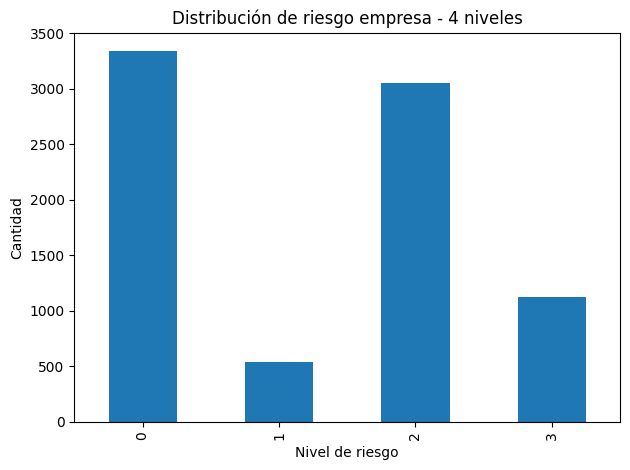

In [10]:
display(df_model.head())
display(df_model.describe(include="all").T.head(40))

if plt is not None:
    ax = df_model[target_col].value_counts().sort_index().plot(kind="bar", title="Distribución de riesgo empresa - 4 niveles")
    ax.set_xlabel("Nivel de riesgo")
    ax.set_ylabel("Cantidad")
    fig = ax.get_figure()
    fig.tight_layout()
    fig.savefig(REPORTS / "empresa_v3_distribucion_4niveles.png", dpi=150)
    plt.show()
else:
    print("matplotlib no disponible")

## 10. Baseline multiclase con split por grupos

Se usa `GroupShuffleSplit` con `CODIGO_RUC` como grupo para evitar que una misma empresa aparezca tanto en entrenamiento como en prueba.

Num cols: 15
Cat cols: 9
Filas: 8047 | Empresas únicas: 371
Train: (6415, 24) Test: (1632, 24)
Distribución train:
y_riesgo_empresa_4niveles
0    2476
1     490
2    2586
3     863
Name: count, dtype: int64
Distribución test:
y_riesgo_empresa_4niveles
0    860
1     50
2    463
3    259
Name: count, dtype: int64
{
  "accuracy": 0.4632352941176471,
  "balanced_accuracy": 0.3952245215731579,
  "macro_f1": 0.27253818693369797,
  "weighted_f1": 0.4003929208952647,
  "n_train": 6415,
  "n_test": 1632,
  "n_empresas_train": 296,
  "n_empresas_test": 75
}

Classification report:
              precision    recall  f1-score   support

           0       0.66      0.57      0.61       860
           1       0.00      0.00      0.00        50
           2       0.12      0.01      0.01       463
           3       0.30      1.00      0.46       259

    accuracy                           0.46      1632
   macro avg       0.27      0.40      0.27      1632
weighted avg       0.43      0.46      0.

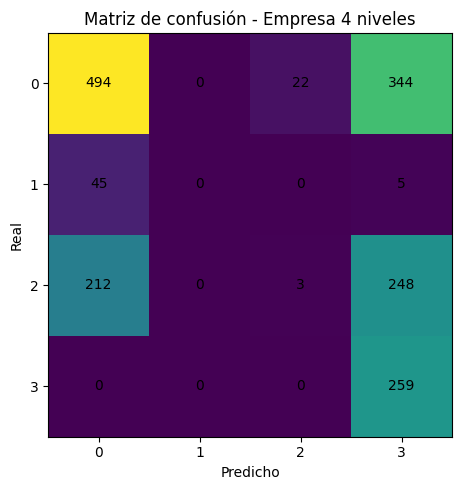

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    accuracy_score,
)
from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

# Preparar X, y, groups
X = df_model.drop(columns=[target_col])
y = df_model[target_col].astype(int)
groups = df_model["CODIGO_RUC"].astype(str)

# Evitar que la clave sea usada como predictor directo
X = X.drop(columns=["CODIGO_RUC"], errors="ignore")

num_cols = X.select_dtypes(include=["number"]).columns.tolist()
cat_cols = X.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

print("Num cols:", len(num_cols))
print("Cat cols:", len(cat_cols))
print("Filas:", len(X), "| Empresas únicas:", groups.nunique())

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución train:")
print(y_train.value_counts().sort_index())
print("Distribución test:")
print(y_test.value_counts().sort_index())

pre = ColumnTransformer([
    ("num", SimpleImputer(strategy="median"), num_cols),
    ("cat", Pipeline([
        ("imp", SimpleImputer(strategy="most_frequent")),
        ("ohe", OneHotEncoder(handle_unknown="ignore")),
    ]), cat_cols),
])

clf = Pipeline([
    ("pre", pre),
    ("model", LogisticRegression(
        max_iter=5000,
        class_weight="balanced",
        solver="lbfgs",
        random_state=42,
    )),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

metrics = {
    "accuracy": float(accuracy_score(y_test, y_pred)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, y_pred)),
    "macro_f1": float(f1_score(y_test, y_pred, average="macro", zero_division=0)),
    "weighted_f1": float(f1_score(y_test, y_pred, average="weighted", zero_division=0)),
    "n_train": int(len(X_train)),
    "n_test": int(len(X_test)),
    "n_empresas_train": int(groups.iloc[train_idx].nunique()),
    "n_empresas_test": int(groups.iloc[test_idx].nunique()),
}

print(json.dumps(metrics, indent=2, ensure_ascii=False))
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1, 2, 3])
print("Matriz de confusión [0,1,2,3]:")
print(cm)

if plt is not None:
    fig, ax = plt.subplots(figsize=(6, 5))
    im = ax.imshow(cm)
    ax.set_title("Matriz de confusión - Empresa 4 niveles")
    ax.set_xlabel("Predicho")
    ax.set_ylabel("Real")
    ax.set_xticks(range(4))
    ax.set_yticks(range(4))
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    fig.tight_layout()
    fig.savefig(REPORTS / "empresa_v3_confusion_matrix_4niveles.png", dpi=150)
    plt.show()

## 11. Guardar datasets y métricas

In [12]:
# Dataset empresa única con target proxy
out_unico_parquet = DATA_PROC / "dataset_empresa_v3_4niveles_unico.parquet"
out_unico_csv = DATA_PROC / "dataset_empresa_v3_4niveles_unico.csv"

empresa_features.to_parquet(out_unico_parquet, index=False)
empresa_features.to_csv(out_unico_csv, index=False, encoding="utf-8-sig")

# Dataset granular completo
out_granular_parquet = DATA_PROC / "dataset_empresa_v3_4niveles_vinculo.parquet"
out_granular_csv = DATA_PROC / "dataset_empresa_v3_4niveles_vinculo.csv"

df_empresa_v3.to_parquet(out_granular_parquet, index=False)
df_empresa_v3.to_csv(out_granular_csv, index=False, encoding="utf-8-sig")

# Dataset modelado sin leakage
out_model_parquet = DATA_PROC / "dataset_empresa_v3_4niveles_model.parquet"
out_model_csv = DATA_PROC / "dataset_empresa_v3_4niveles_model.csv"

df_model.to_parquet(out_model_parquet, index=False)
df_model.to_csv(out_model_csv, index=False, encoding="utf-8-sig")

# Metadatos
meta = {
    "descripcion": "Dataset Empresa V3 con 4 niveles de riesgo proxy",
    "unidad_analisis": "empresa-vinculo ganador/participante",
    "target": target_col,
    "niveles": {
        "0": "Sin señales relevantes",
        "1": "Riesgo bajo",
        "2": "Riesgo medio",
        "3": "Riesgo alto/extremo",
    },
    "nota_target": "Etiqueta proxy construida a partir de sanciones, inhabilitaciones, impedimentos y alertas.",
    "cols_leakage_excluidas": cols_leakage,
    "shape_empresa_unica": list(empresa_features.shape),
    "shape_granular": list(df_empresa_v3.shape),
    "shape_model": list(df_model.shape),
    "distribucion_target_model": {str(k): int(v) for k, v in df_model[target_col].value_counts().sort_index().to_dict().items()},
    "metrics_baseline": metrics,
}

out_meta = DATA_PROC / "dataset_empresa_v3_4niveles_meta.json"
out_metrics = DATA_PROC / "baseline_empresa_v3_4niveles_metrics.json"

out_meta.write_text(json.dumps(meta, indent=2, ensure_ascii=False), encoding="utf-8")
out_metrics.write_text(json.dumps(metrics, indent=2, ensure_ascii=False), encoding="utf-8")

print("Guardado:")
print("-", out_unico_parquet)
print("-", out_unico_csv)
print("-", out_granular_parquet)
print("-", out_granular_csv)
print("-", out_model_parquet)
print("-", out_model_csv)
print("-", out_meta)
print("-", out_metrics)

Guardado:
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_unico.parquet
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_unico.csv
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_vinculo.parquet
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_vinculo.csv
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_model.parquet
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_model.csv
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\dataset_empresa_v3_4niveles_meta.json
- C:\IA_Investigacion\Deteccion_Corrupcion\data\processed\baseline_empresa_v3_4niveles_metrics.json


## 12. Conclusión metodológica

Este notebook incrementa la granularidad pasando de empresa única a **empresa–vínculo**, usando las relaciones ganador–participante.

Puntos importantes para la exposición:

1. No existe una etiqueta explícita `RIESGO_EMPRESA`; se construye una etiqueta proxy.
2. Las variables usadas para construir el target se excluyen del entrenamiento.
3. El split se realiza por `CODIGO_RUC`, evitando que la misma empresa aparezca en train y test.
4. El baseline es una primera línea base, no un modelo final.
5. Las métricas relevantes para multiclase desbalanceado son `balanced_accuracy`, `macro_f1`, matriz de confusión y `classification_report`.